In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

In [2]:
df = pd.read_csv('Assignment1_mimic dataset.csv')
df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,deathtime,icu_death_flag,...,ck_mb_min,ck_mb_max,ggt_min,ggt_max,ld_ldh_min,ld_ldh_max,so2_min,so2_max,po2_min,po2_max
0,10270110,20171261,35854639,PACU,PACU,2134-03-25T03:32:02Z,2134-03-25T14:20:42Z,0.450463,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10270644,20019675,35548343,PACU,PACU,2159-12-03T16:20:31Z,2159-12-08T17:28:42Z,5.047350,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10464753,28216499,32421516,PACU,PACU,2183-01-10T20:51:04Z,2183-01-11T22:58:45Z,1.088669,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10710188,21362776,34067486,PACU,PACU,2147-06-22T11:48:40Z,2147-06-23T11:35:59Z,0.991192,2147-06-23T14:21:00Z,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10826759,28468289,37075137,PACU,PACU,2121-05-19T18:07:00Z,2121-05-20T16:32:39Z,0.934479,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## EDA

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65366 entries, 0 to 65365
Columns: 140 entries, subject_id to po2_max
dtypes: float64(124), int64(6), object(10)
memory usage: 69.8+ MB


,subject_id,hadm_id,stay_id,los,icu_death_flag,hospital_expire_flag,age,sofa2_respiration_24h_max,sofa2_cardiovascular_24h_max,sofa2_coagulation_24h_max,...,ck_mb_min,ck_mb_max,ggt_min,ggt_max,ld_ldh_min,ld_ldh_max,so2_min,so2_max,po2_min,po2_max
count,6.536600e+04,6.536600e+04,6.536600e+04,65355.000000,65366.000000,65366.000000,65366.000000,65365.000000,65365.000000,65365.000000,...,4245.000000,4245.000000,105.000000,105.000000,5220.000000,5220.000000,15494.000000,15494.000000,30998.000000,30998.000000
mean,1.499849e+07,2.497702e+07,3.499761e+07,3.558663,0.086758,0.108405,64.533611,0.163130,0.494026,0.327836,...,18.918163,32.041366,173.561905,173.742857,470.687356,578.817433,94.804950,96.609894,115.957417,261.419640
std,2.887822e+06,2.884736e+06,2.890204e+06,5.273775,0.281482,0.310894,17.127307,0.576018,0.963670,0.803824,...,47.192486,75.140309,311.517839,311.436530,915.851109,1283.856463,6.405936,4.599179,70.874929,144.148943
min,1.000003e+07,2.000009e+07,3.000115e+07,0.001250,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,4.000000,4.000000,31.000000,31.000000,4.000000,9.000000,2.000000,16.000000
25%,1.250235e+07,2.247845e+07,3.249497e+07,1.100330,0.000000,0.000000,54.000000,0.000000,0.000000,0.000000,...,2.000000,3.000000,27.000000,27.000000,199.000000,208.000000,94.000000,96.000000,75.000000,124.000000
50%,1.500045e+07,2.496176e+07,3.499794e+07,1.932037,0.000000,0.000000,66.000000,0.000000,0.000000,0.000000,...,4.000000,6.000000,74.000000,76.000000,270.000000,290.000000,96.000000,98.000000,95.000000,244.000000
75%,1.750965e+07,2.746640e+07,3.749812e+07,3.759219,0.000000,0.000000,78.000000,0.000000,1.000000,0.000000,...,11.000000,18.000000,195.000000,195.000000,411.250000,460.000000,98.000000,98.000000,133.000000,392.000000
max,1.999999e+07,2.999983e+07,3.999986e+07,226.403079,1.000000,1.000000,103.000000,4.000000,4.000000,4.000000,...,550.000000,597.000000,2720.000000,2720.000000,21640.000000,30200.000000,100.000000,100.000000,667.000000,795.000000


#### 130 numerical variables, 10 other variables (like categorical variables and datetime variables)

In [6]:
print("Shape:", df.shape)

Shape: (65366, 140)


#### focus on icu_death_flag = 0 relates to which variables

In [8]:
print(df['hospital_expire_flag'].value_counts())
print(df['hospital_expire_flag'].value_counts(normalize=True))

hospital_expire_flag
0    58280
1     7086
Name: count, dtype: int64
hospital_expire_flag
0    0.891595
1    0.108405
Name: proportion, dtype: float64


### duplicated and missing values

In [10]:
df.duplicated().sum()

0

In [11]:
df['subject_id'].nunique()

65366

In [12]:
# Missing values
missing_ratio = df.isnull().mean().sort_values(ascending=False)
missing_ratio.head(20)

thrombin_max              0.999480
thrombin_min              0.999480
ggt_min                   0.998394
ggt_max                   0.998394
globulin_min              0.997506
globulin_max              0.997506
d_dimer_min               0.996803
d_dimer_max               0.996803
total_protein_max         0.994768
total_protein_min         0.994768
bilirubin_indirect_max    0.990683
bilirubin_indirect_min    0.990683
amylase_max               0.990132
amylase_min               0.990132
bilirubin_direct_max      0.989765
bilirubin_direct_min      0.989765
nrbc_max                  0.988052
nrbc_min                  0.988052
atyps_max                 0.977144
atyps_min                 0.977144
dtype: float64

In [13]:
# Drop columns with >40% missing values
high_missing_cols = missing_ratio[missing_ratio > 0.4].index
df_clean = df.drop(columns=high_missing_cols)
df_clean.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,icu_death_flag,insurance,...,spo2_max,spo2_mean,glucose_min,glucose_max,glucose_mean,gcs_min,gcs_motor,gcs_verbal,gcs_eyes,gcs_unable
0,10270110,20171261,35854639,PACU,PACU,2134-03-25T03:32:02Z,2134-03-25T14:20:42Z,0.450463,0,Medicaid,...,98.0,94.222222,148.0,148.0,148.000000,15.0,6.0,5.0,4.0,0.0
1,10270644,20019675,35548343,PACU,PACU,2159-12-03T16:20:31Z,2159-12-08T17:28:42Z,5.047350,0,Medicare,...,100.0,97.720000,121.0,212.0,158.916667,10.0,4.0,4.0,2.0,0.0
2,10464753,28216499,32421516,PACU,PACU,2183-01-10T20:51:04Z,2183-01-11T22:58:45Z,1.088669,0,Medicare,...,100.0,98.741935,134.0,135.0,134.500000,9.0,6.0,1.0,2.0,0.0
3,10710188,21362776,34067486,PACU,PACU,2147-06-22T11:48:40Z,2147-06-23T11:35:59Z,0.991192,1,Medicare,...,100.0,98.000000,133.0,147.0,140.000000,15.0,1.0,0.0,1.0,1.0
4,10826759,28468289,37075137,PACU,PACU,2121-05-19T18:07:00Z,2121-05-20T16:32:39Z,0.934479,0,Medicare,...,100.0,96.777778,123.0,123.0,123.000000,14.0,6.0,5.0,3.0,0.0


In [14]:
# Reduce cardinality of categorical features before splitting
def reduce_cardinality(series, min_freq=0.01, other_label='OTHER'):
    freqs = series.value_counts(normalize=True, dropna=False)
    rare = freqs[freqs < min_freq].index
    return series.apply(lambda x: other_label if x in rare else x)

# combine similar or rare race categories
if 'race' in df_clean.columns:
    df_clean['race'] = df_clean['race'].replace({'Asian-China': 'Asian'})
    df_clean['race'] = reduce_cardinality(df_clean['race'].astype(str), min_freq=0.02)

# do the same for other high‑cardinality fields
for col in ['ethnicity', 'insurance', 'marital_status']:
    if col in df_clean.columns:
        df_clean[col] = reduce_cardinality(df_clean[col].astype(str))

In [15]:
# Drop identity columns
identity_cols = ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'deathtime','los', 'icu_death_flag']
df_clean = df_clean.drop(columns=[col for col in identity_cols if col in df_clean.columns])


print(f"\nShape after initial cleaning: {df_clean.shape}")
print(f"\nRemaining features: {df_clean.columns.tolist()}")


Shape after initial cleaning: (65366, 44)

Remaining features: ['first_careunit', 'last_careunit', 'insurance', 'language', 'race', 'marital_status', 'hospital_expire_flag', 'age', 'gender', 'sofa2_respiration_24h_max', 'sofa2_cardiovascular_24h_max', 'sofa2_coagulation_24h_max', 'sofa2_liver_24h_max', 'sofa2_renal_24h_max', 'sofa2_cns_24h_max', 'heart_rate_min', 'heart_rate_max', 'heart_rate_mean', 'sbp_min', 'sbp_max', 'sbp_mean', 'dbp_min', 'dbp_max', 'dbp_mean', 'mbp_min', 'mbp_max', 'mbp_mean', 'resp_rate_min', 'resp_rate_max', 'resp_rate_mean', 'temperature_min', 'temperature_max', 'temperature_mean', 'spo2_min', 'spo2_max', 'spo2_mean', 'glucose_min', 'glucose_max', 'glucose_mean', 'gcs_min', 'gcs_motor', 'gcs_verbal', 'gcs_eyes', 'gcs_unable']


### numerical and categorical variables (scaling and encoding)

In [17]:
# Separate target
X = df_clean.drop(columns=['hospital_expire_flag'])
y = df_clean['hospital_expire_flag'].fillna(0).astype(int)

In [18]:
# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

In [19]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_cols = [col for col in numeric_cols if col in X_train.columns]
categorical_cols = [col for col in categorical_cols if col in X_train.columns]

if len(categorical_cols) == 0:
    print("Warning: There is no classification column.")

In [20]:
# Impute missing values
num_imputer = SimpleImputer(strategy="median")
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[numeric_cols]),
                           columns=numeric_cols, index=X_train.index)
X_test_num  = pd.DataFrame(num_imputer.transform(X_test[numeric_cols]),
                           columns=numeric_cols, index=X_test.index)

if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[categorical_cols]),
                               columns=categorical_cols, index=X_train.index)
    X_test_cat  = pd.DataFrame(cat_imputer.transform(X_test[categorical_cols]),
                               columns=categorical_cols, index=X_test.index)
else:
    X_train_cat = pd.DataFrame(index=X_train.index)
    X_test_cat  = pd.DataFrame(index=X_test.index)

In [29]:
# One-hot encoding categorical variables
if len(categorical_cols) > 0:
    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    X_train_cat_encoded = encoder.fit_transform(X_train_cat)
    X_test_cat_encoded  = encoder.transform(X_test_cat)

    cat_encoded_columns = encoder.get_feature_names_out(categorical_cols)
    X_train_cat_encoded = pd.DataFrame(X_train_cat_encoded,
                                       columns=cat_encoded_columns,
                                       index=X_train.index)
    X_test_cat_encoded = pd.DataFrame(X_test_cat_encoded,
                                      columns=cat_encoded_columns,
                                      index=X_test.index)
else:
    X_train_cat_encoded = pd.DataFrame(index=X_train.index)
    X_test_cat_encoded = pd.DataFrame(index=X_test.index)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:241: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [31]:
# Align columns
X_train_full = pd.concat([X_train_num, X_train_cat_encoded], axis=1)
X_test_full  = pd.concat([X_test_num,  X_test_cat_encoded], axis=1)

In [32]:
# Scaling numerical variables
scaler = StandardScaler()
X_train_full[numeric_cols] = scaler.fit_transform(X_train_full[numeric_cols])
X_test_full[numeric_cols] = scaler.transform(X_test_full[numeric_cols])

In [33]:
print("Final train shape:", X_train_full.shape)
print("Final test shape:", X_test_full.shape)

Final train shape: (45756, 103)
Final test shape: (19610, 103)


## Feature selection methods

#### Variance + Correlation

In [36]:
print("Original feature count:", X_train_full.shape[1])

# -------- Variance Filter --------
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_train_full)

X_train_var = X_train_full.loc[:, var_selector.get_support()]
X_test_var = X_test_full.loc[:, var_selector.get_support()]

print("After Variance Filter:", X_train_var.shape[1])

# -------- Correlation Filter --------
corr_matrix = X_train_var.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold_corr = 0.8

to_drop = [column for column in upper.columns if any(upper[column] > threshold_corr)]

print("Highly correlated features removed:", len(to_drop))

X_train_stage1 = X_train_var.drop(columns=to_drop)
X_test_stage1 = X_test_var.drop(columns=to_drop, errors='ignore')

print("After Correlation Filter:", X_train_stage1.shape[1])

Original feature count: 103
After Variance Filter: 70
Highly correlated features removed: 14
After Correlation Filter: 56


#### L1

In [38]:
C_values = [0.01, 0.1, 0.5, 1, 5, 10]
results_l1 = []

print("\n--- L1 Path Experiment ---")
for C in C_values:
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=500, class_weight='balanced')
    auc = cross_val_score(model, X_train_stage1, y_train, cv=5, scoring='roc_auc').mean()
    model.fit(X_train_stage1, y_train)
    non_zero = np.sum(model.coef_[0] != 0)
    
    print(f"C={C} | Selected={non_zero} | CV AUC={auc:.4f}")
    results_l1.append((C, non_zero, auc))

results_l1_df = pd.DataFrame(results_l1, columns=["C", "Selected_Features", "CV_AUC"])
results_l1_df


--- L1 Path Experiment ---
C=0.01 | Selected=40 | CV AUC=0.8884
C=0.1 | Selected=50 | CV AUC=0.8954
C=0.5 | Selected=56 | CV AUC=0.8956
C=1 | Selected=56 | CV AUC=0.8956
C=5 | Selected=56 | CV AUC=0.8956
C=10 | Selected=56 | CV AUC=0.8956


,C,Selected_Features,CV_AUC
0,0.01,40,0.888404
1,0.10,50,0.895426
2,0.50,56,0.895572
3,1.00,56,0.895584
4,5.00,56,0.895581
5,10.00,56,0.895580


In [39]:
final_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=500, class_weight='balanced')
final_l1.fit(X_train_stage1, y_train)

coef = final_l1.coef_[0]
selected_mask_l1 = coef != 0

selected_features_l1 = X_train_stage1.columns[selected_mask_l1]
l1_auc = 0.895426

print("Final L1 selected feature count:", len(selected_features_l1))

Final L1 selected feature count: 50


In [40]:
X_train_l1 = X_train_stage1[selected_features_l1]
X_test_l1 = X_test_stage1[selected_features_l1]

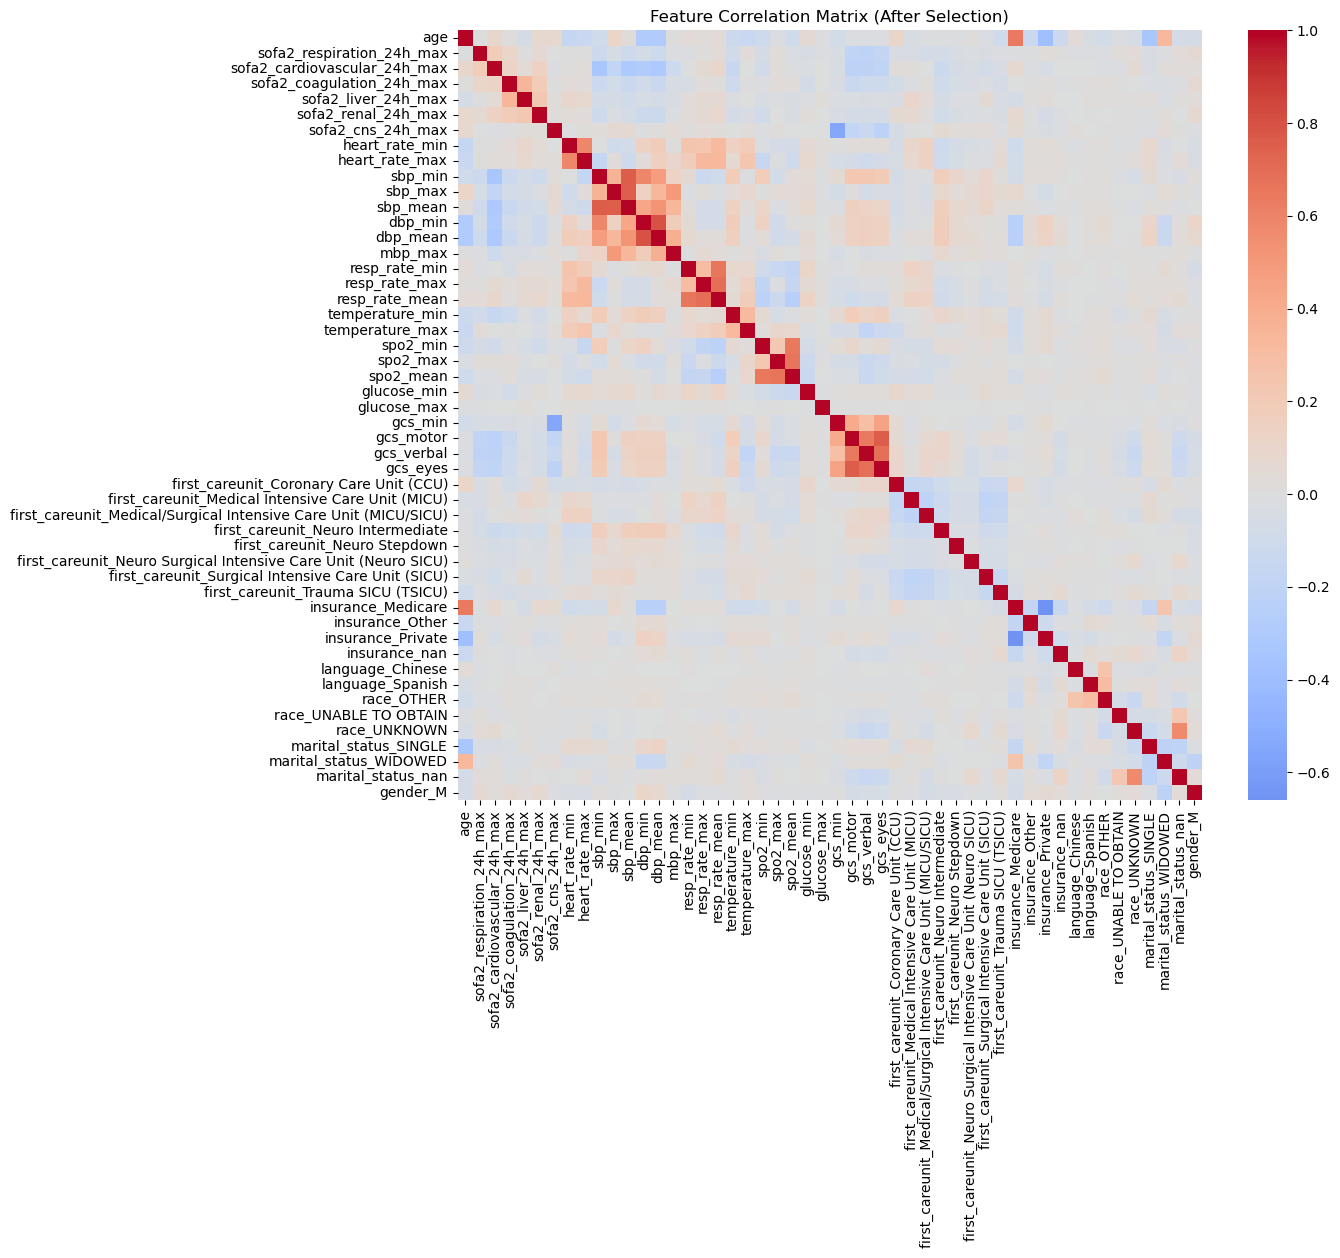

In [41]:
plt.figure(figsize=(12,10))
corr_selected = X_train_l1.corr()
sns.heatmap(corr_selected, cmap='coolwarm', center=0, xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Matrix (After Selection)')
plt.show()

In [42]:
corr_with_target = X_train_l1.corrwith(y_train).abs().sort_values(ascending=False)
print("\nTop 10 Features Correlated with Target (absolute value):")
print(corr_with_target.head(10))


Top 10 Features Correlated with Target (absolute value):
gcs_motor              0.286565
gcs_eyes               0.275259
spo2_min               0.253034
gcs_verbal             0.248895
resp_rate_mean         0.240537
sbp_min                0.224151
spo2_mean              0.190403
dbp_min                0.173257
heart_rate_max         0.169747
sofa2_liver_24h_max    0.169012
dtype: float64


#### L2 comparison

In [44]:
print("\n--- L2 Comparison ---")
l2_model = LogisticRegression(penalty='l2', solver='liblinear', C=0.1, max_iter=500, class_weight='balanced')
l2_auc = cross_val_score(l2_model, X_train_stage1, y_train, cv=5, scoring='roc_auc').mean()

print("L2 CV AUC:", l2_auc)


--- L2 Comparison ---
L2 CV AUC: 0.8949929837162607


In [45]:
comparison_df = pd.DataFrame({
    "Method": ["L1", "L2"],
    "Feature_Count": [len(selected_features_l1), X_train_stage1.shape[1]],
    "CV_AUC": [l1_auc, l2_auc]
})

comparison_df

,Method,Feature_Count,CV_AUC
0,L1,50,0.895426
1,L2,56,0.894993


## predictive models

In [47]:
def evaluate_model(y_true, y_prob, y_pred):
    return {
        "AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

In [48]:
scaler_50 = StandardScaler()
X_train_l1_scaled = scaler_50.fit_transform(X_train_l1)
X_test_l1_scaled = scaler_50.transform(X_test_l1)

#### Logistic regression

In [50]:
lr_model = LogisticRegression(
    C=1.0, 
    max_iter=2000, 
    random_state=42,
    class_weight='balanced'  
)
lr_model.fit(X_train_l1_scaled, y_train)

lr_prob = lr_model.predict_proba(X_test_l1_scaled)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)
lr_metrics = evaluate_model(y_test, lr_prob, lr_pred)
print(f"Logistic AUC: {lr_metrics['AUC']:.4f}")

Logistic AUC: 0.8878


#### Random forest

In [52]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  
)
rf_model.fit(X_train_l1, y_train)  

rf_prob = rf_model.predict_proba(X_test_l1)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)
rf_metrics = evaluate_model(y_test, rf_prob, rf_pred)
print(f"Random Forest AUC: {rf_metrics['AUC']:.4f}")

Random Forest AUC: 0.9004


#### Decision tree

In [54]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train_l1, y_train)

dt_prob = dt_model.predict_proba(X_test_l1)[:, 1]
dt_pred = (dt_prob >= 0.5).astype(int)
dt_metrics = evaluate_model(y_test, dt_prob, dt_pred)
print(f"Decision Tree AUC: {dt_metrics['AUC']:.4f}")

Decision Tree AUC: 0.8193


#### SVM

In [56]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42,
    class_weight='balanced'
)
svm_model.fit(X_train_l1_scaled, y_train) 

svm_prob = svm_model.predict_proba(X_test_l1_scaled)[:, 1]
svm_pred = (svm_prob >= 0.5).astype(int)
svm_metrics = evaluate_model(y_test, svm_prob, svm_pred)
print(f"SVM AUC: {svm_metrics['AUC']:.4f}")

SVM AUC: 0.9006


#### XGBoost

In [58]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),  # 处理不平衡
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_l1, y_train)

xgb_prob = xgb_model.predict_proba(X_test_l1)[:, 1]
xgb_pred = (xgb_prob >= 0.5).astype(int)
xgb_metrics = evaluate_model(y_test, xgb_prob, xgb_pred)
print(f"XGBoost AUC: {xgb_metrics['AUC']:.4f}")

XGBoost AUC: 0.9067


In [60]:
results_50 = pd.DataFrame.from_dict({
    "Logistic Regression": lr_metrics,
    "Random Forest": rf_metrics,
    "Decision Tree": dt_metrics,
    "SVM": svm_metrics,
    "XGBoost": xgb_metrics
}, orient="index")

results_50 = results_50.sort_values(by="AUC", ascending=False)

print("Model performance comparison(50 features, C=0.1)")
print(results_50.round(4))

Model performance comparison(50 features, C=0.1)
                        AUC  Accuracy  Precision  Recall      F1
XGBoost              0.9067    0.8438     0.3915  0.7963  0.5250
SVM                  0.9006    0.9064     0.6095  0.3796  0.4678
Random Forest        0.9004    0.9171     0.7451  0.3575  0.4832
Logistic Regression  0.8878    0.8157     0.3475  0.7977  0.4842
Decision Tree        0.8193    0.7711     0.2800  0.7070  0.4011


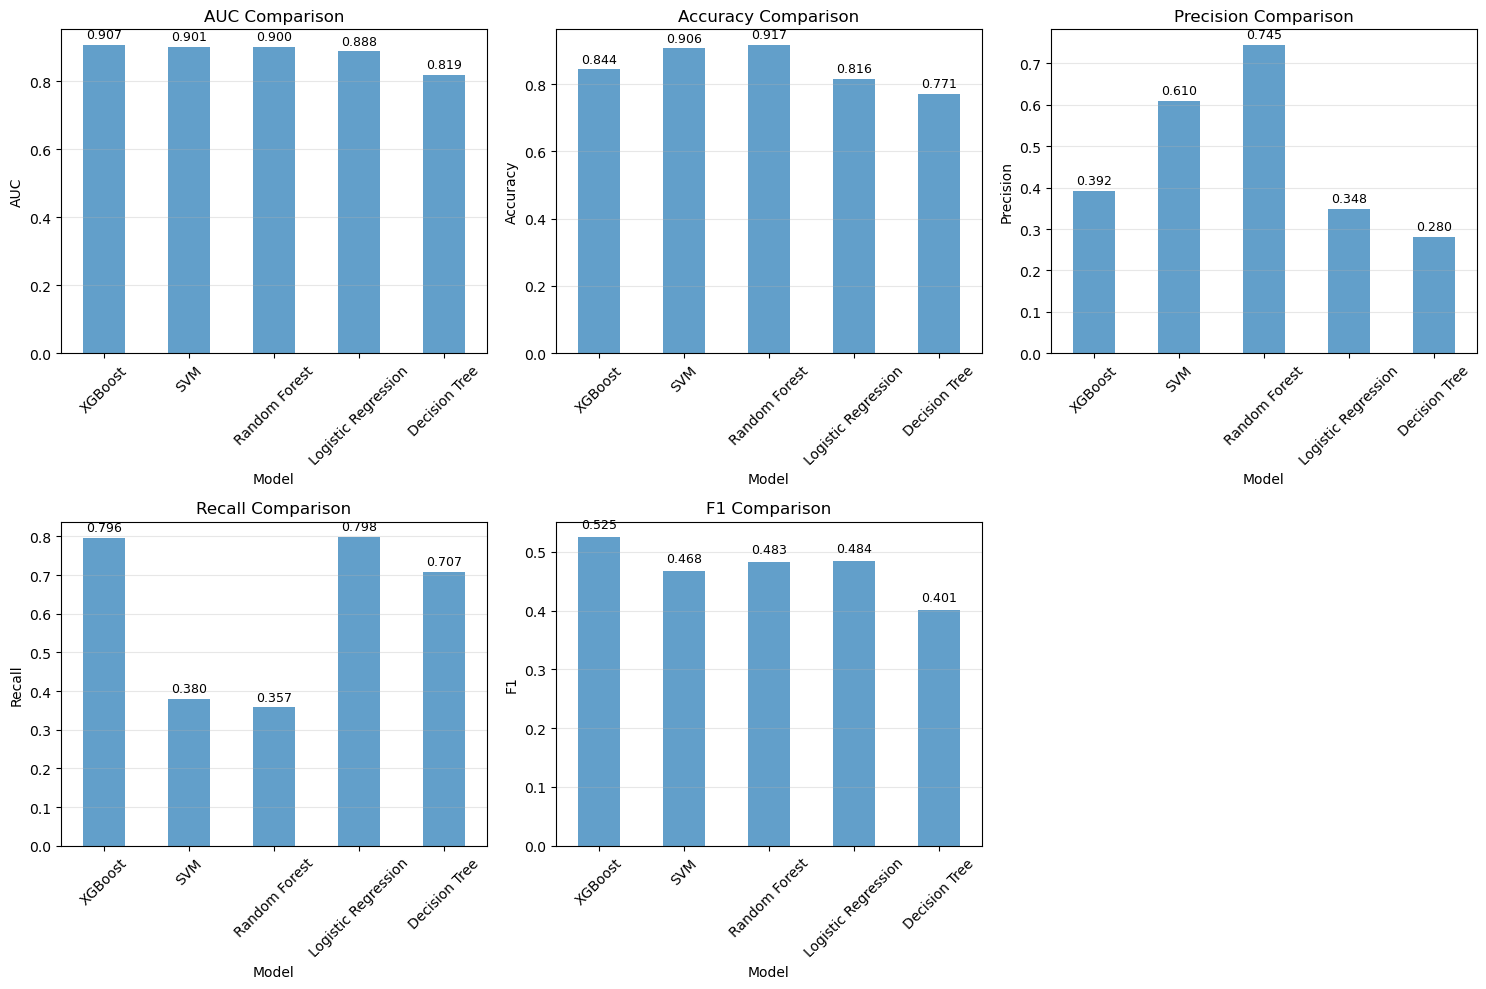

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']

for i, metric in enumerate(metrics):
    ax = axes[i]
    results_50[metric].plot(kind='bar', ax=ax, alpha=0.7)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    for j, v in enumerate(results_50[metric]):
        ax.text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

for i in range(len(metrics), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison_50_features.png', dpi=150, bbox_inches='tight')
plt.show()

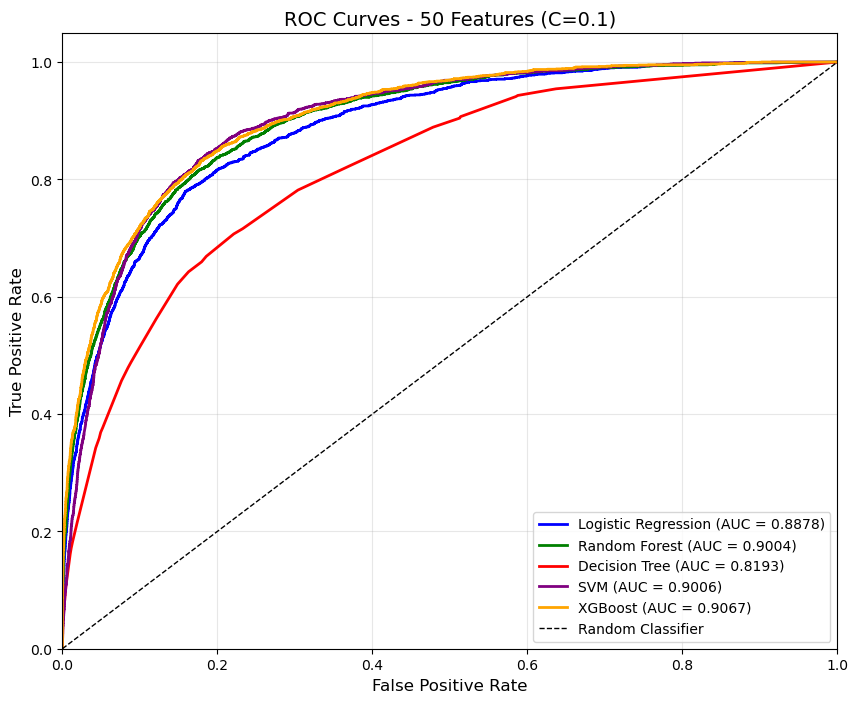

In [63]:
# ROC
plt.figure(figsize=(10, 8))

models_data = [
    (lr_model, "Logistic Regression", X_test_l1_scaled, 'blue'),
    (rf_model, "Random Forest", X_test_l1, 'green'),
    (dt_model, "Decision Tree", X_test_l1, 'red'),
    (svm_model, "SVM", X_test_l1_scaled, 'purple'),
    (xgb_model, "XGBoost", X_test_l1, 'orange')
]

for model, name, X_test_data, color in models_data:
    y_prob = model.predict_proba(X_test_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - 50 Features (C=0.1)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('roc_curves_50_features.png', dpi=150, bbox_inches='tight')
plt.show()

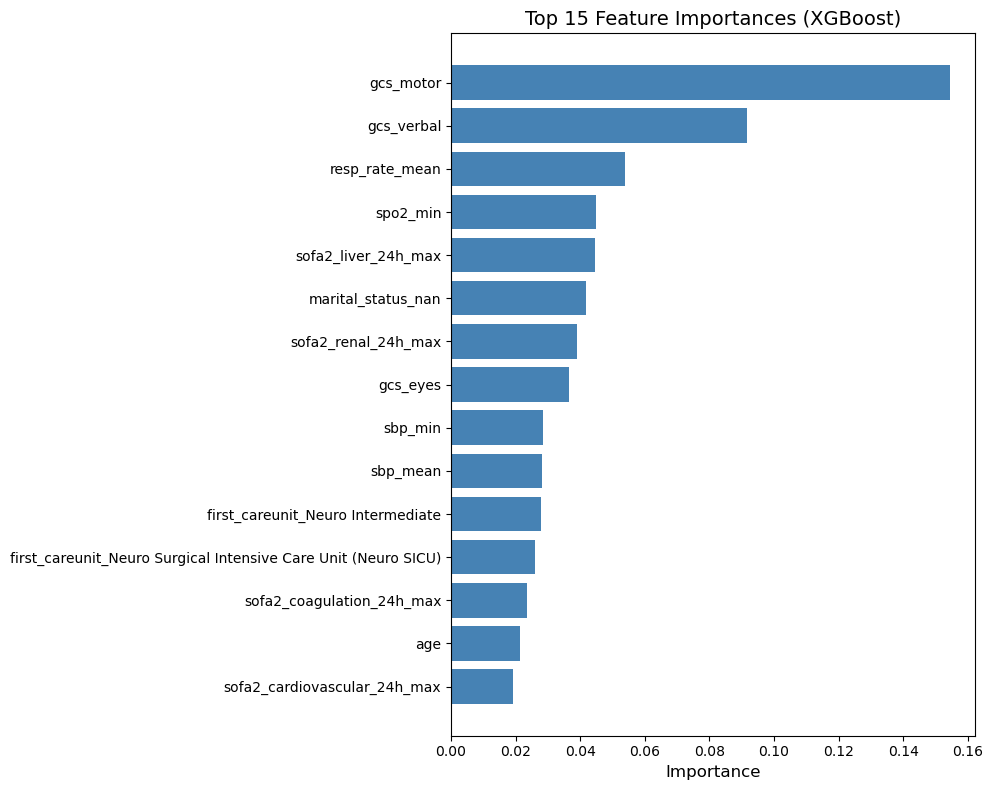

In [65]:
# Obtain the feature importance from the XGBoost model
xgb_importances = xgb_model.feature_importances_
feature_names = X_train_l1.columns  

importance_df = pd.DataFrame({'feature': feature_names, 'importance': xgb_importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=14)
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.savefig('Top 15 Feature Importances (XGBoost).png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
print("Top 15 Features by XGBoost Importance:")
print(importance_df.to_string(index=False))

Top 15 Features by XGBoost Importance:
                                                       feature  importance
                                                     gcs_motor    0.154437
                                                    gcs_verbal    0.091727
                                                resp_rate_mean    0.053834
                                                      spo2_min    0.045000
                                           sofa2_liver_24h_max    0.044630
                                            marital_status_nan    0.041649
                                           sofa2_renal_24h_max    0.038830
                                                      gcs_eyes    0.036465
                                                       sbp_min    0.028518
                                                      sbp_mean    0.028194
                             first_careunit_Neuro Intermediate    0.027698
first_careunit_Neuro Surgical Intensive Care Unit (Neuro SICU

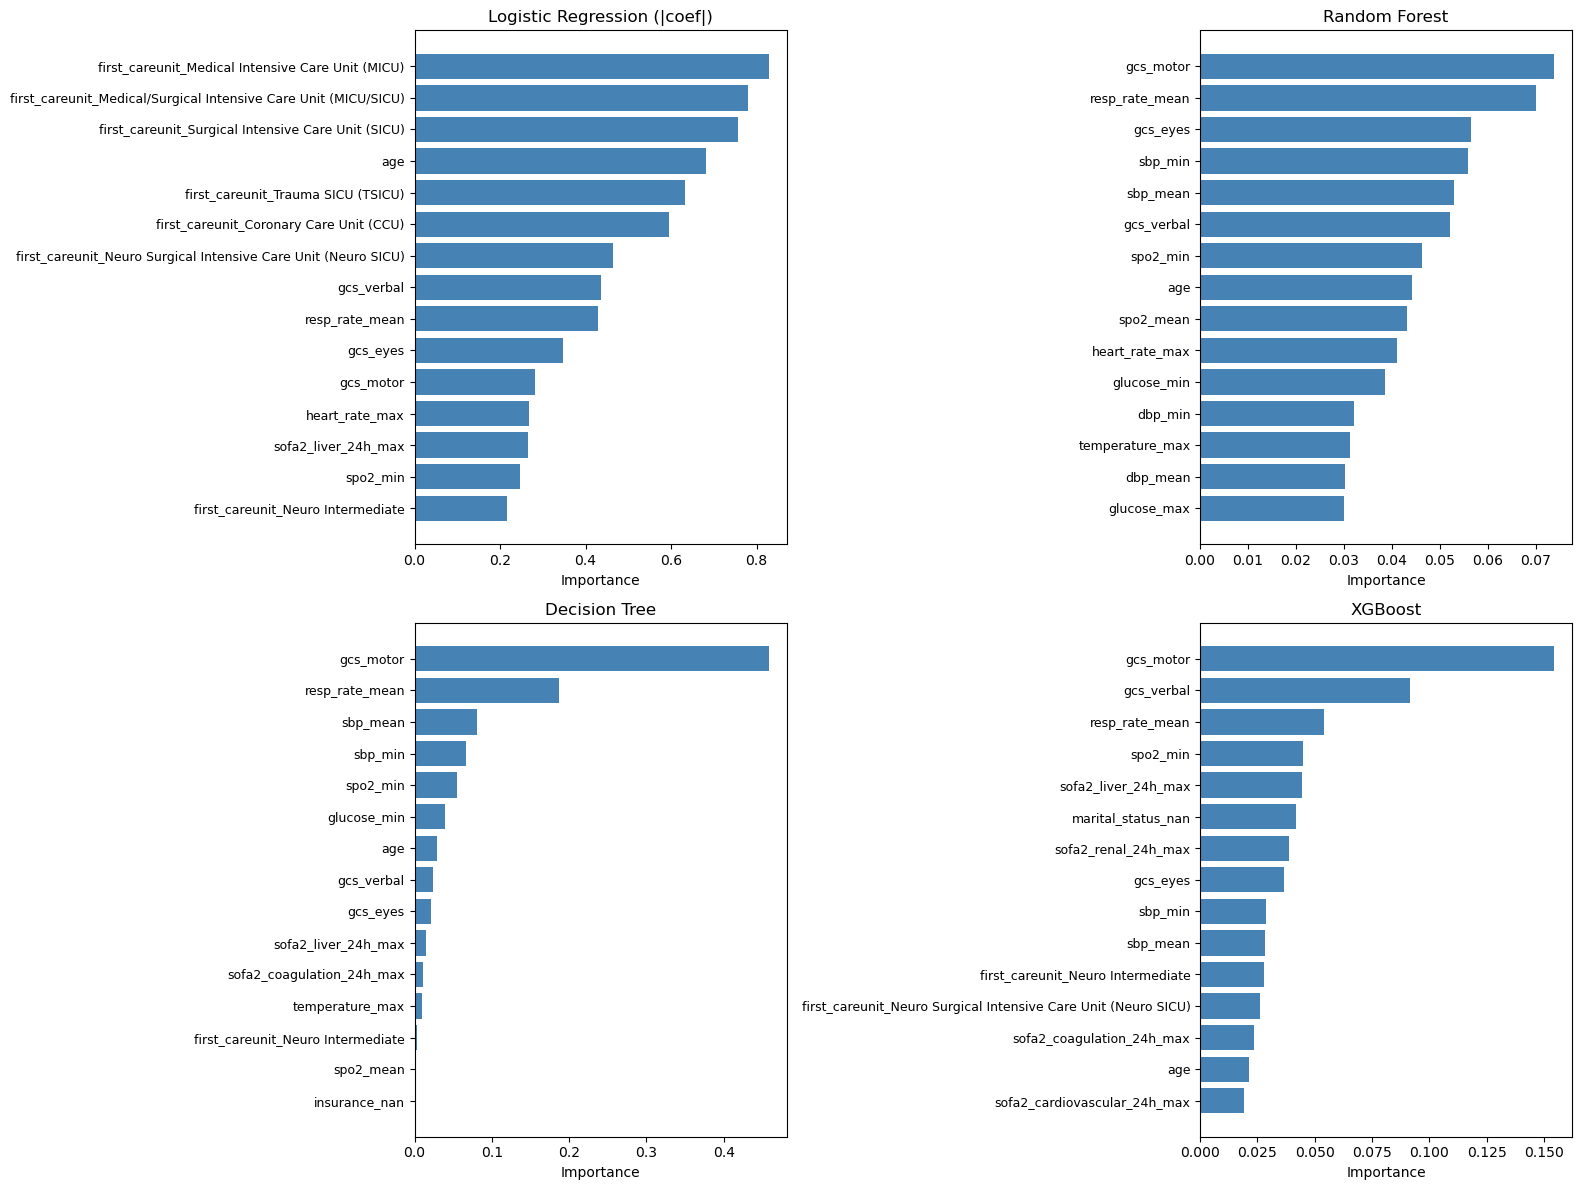

In [67]:
feature_names_50 = X_train_l1.columns

# 1. Logistic Regression
lr_coef = lr_model.coef_[0]               
lr_importance = pd.DataFrame({
    'feature': feature_names_50,
    'importance': np.abs(lr_coef)
}).sort_values('importance', ascending=False).head(15)

# 2. Random Forest 
rf_importance = pd.DataFrame({
    'feature': feature_names_50,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# 3. Decision Tree 
dt_importance = pd.DataFrame({
    'feature': feature_names_50,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# 4. XGBoost
xgb_importance = pd.DataFrame({
    'feature': feature_names_50,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models_data = [
    (lr_importance, "Logistic Regression (|coef|)", axes[0]),
    (rf_importance, "Random Forest", axes[1]),
    (dt_importance, "Decision Tree", axes[2]),
    (xgb_importance, "XGBoost", axes[3])
]

for imp_df, title, ax in models_data:
    ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
    ax.set_xlabel('Importance', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()                    
    ax.tick_params(axis='y', labelsize=9) 

plt.tight_layout()
plt.show()